# Validation of Inflow

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pathlib

In [30]:
def load_data(file_path):
    df = pd.read_excel(file_path, header=None)
    return df

In [31]:
#les samlet byggaktivitet og hent rad 3 (år) + rad 7 (antall bygg)
inflow_val_data = load_data("Samlet_byggaktivitet_42-25.xlsx")

time = pd.to_numeric(inflow_val_data.iloc[2, :], errors="coerce")      # rad 3
inflow = pd.to_numeric(inflow_val_data.iloc[6, :], errors="coerce")    # rad 7

mask = time.notna() & inflow.notna()
time = time[mask].astype(int).to_numpy()
inflow = inflow[mask].to_numpy()

print("time:", time)
print("inflow:", inflow)

time: [1943 1944 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956
 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
inflow: [12629. 12337.  8375.  8269.  9449. 15558. 19496. 16639. 17373. 15559.
 17583. 19000. 19375. 15982. 22507. 16225. 20625. 21294. 22981. 24623.
 24474. 37231. 38269. 37606. 42644. 43457. 48515. 49247. 45142. 47145.
 52290. 47071. 34326. 38322. 35632. 33078. 30197. 29287. 20944. 19701.
 20839. 25552. 21957. 26963. 26457. 24739. 24875. 25240. 18866. 14873.
 12229. 11888. 12067. 12399. 15396. 15878. 14719. 13917. 15047. 16267.
 21139. 23458. 23923. 25004. 28655. 23358. 15844.  9991. 11320. 14263.
 13423. 13917. 13322. 18089. 22555. 25458. 30137. 34426. 31505. 361

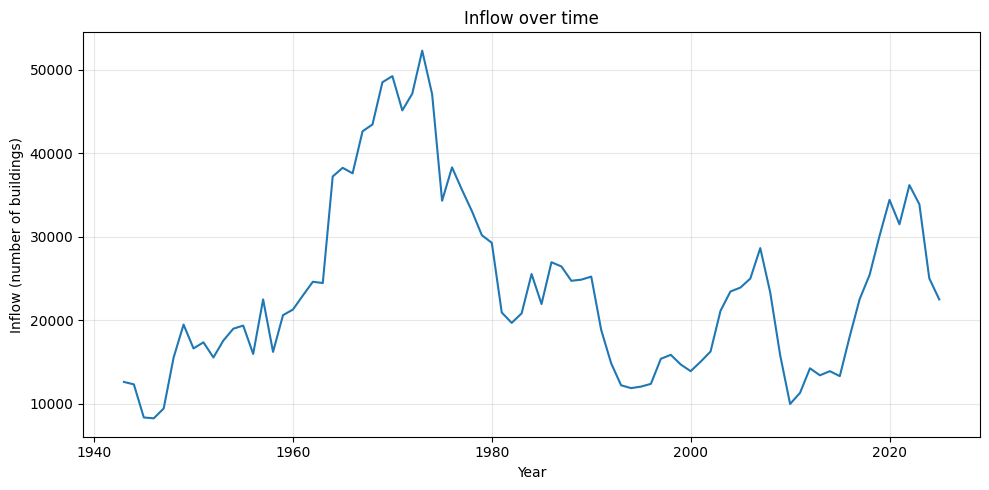

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(time, inflow, color="tab:blue")
plt.title("Inflow over time")
plt.xlabel("Year")
plt.ylabel("Inflow (number of buildings)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

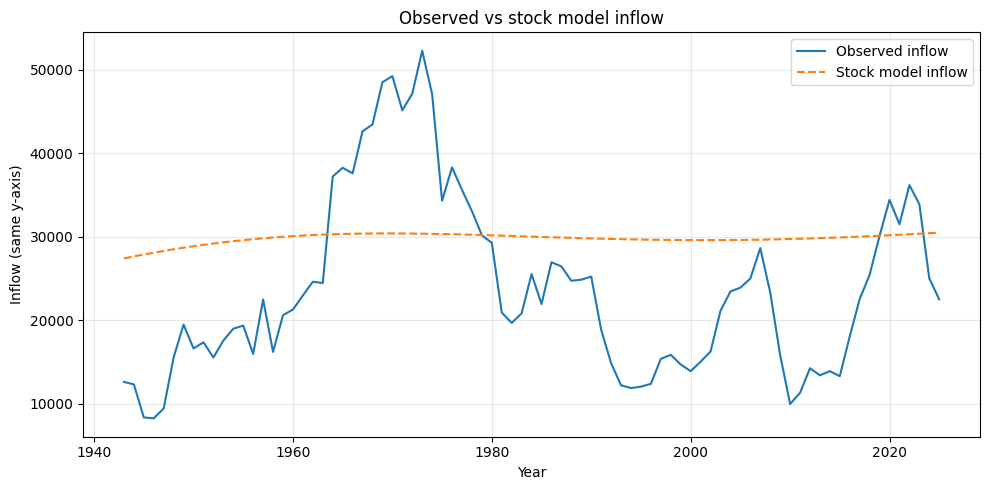

In [33]:
# Sammenligning mot inflows fra stock model (samme y-akse)
if "Inflows_by_time_f" in globals():
    inflow_model = np.asarray(Inflows_by_time_f, dtype=float)
else:
    import json, re
    with open("stock_model.ipynb", "r", encoding="utf-8") as f:
        stock_nb = json.load(f)
    inflow_model = None
    for cell in stock_nb.get("cells", []):
        source = "".join(cell.get("source", []))
        if "print(Inflows_by_time_f)" in source:
            for out in cell.get("outputs", []):
                if out.get("output_type") == "stream" and out.get("name") == "stdout":
                    text = "".join(out.get("text", []))
                    nums = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+(?:[eE][-+]?\d+)", text)
                    if nums:
                        inflow_model = np.array([float(x) for x in nums])
                        break
            if inflow_model is not None:
                break
    if inflow_model is None:
        raise ValueError("Fant ikke Inflows_by_time_f i stock_model.ipynb")

time_model = np.arange(1600, 1600 + len(inflow_model))
model_on_obs_years = pd.Series(inflow_model, index=time_model).reindex(time).interpolate().ffill().bfill().values

plt.figure(figsize=(10, 5))
plt.plot(time, inflow, label="Observed inflow", color="tab:blue")
plt.plot(time, model_on_obs_years, label="Stock model inflow", color="tab:orange", linestyle="--")
plt.title("Observed vs stock model inflow")
plt.xlabel("Year")
plt.ylabel("Inflow (same y-axis)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

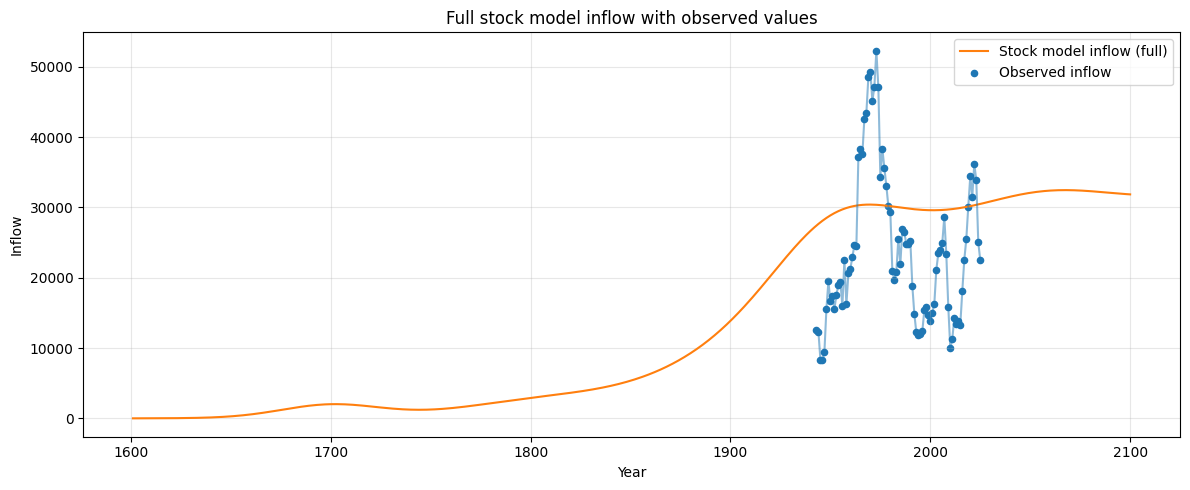

In [35]:
# Full stock model-graf + observerte verdier oppå (uten første spike)
if "Inflows_by_time_f" in globals():
    inflow_model_full = np.asarray(Inflows_by_time_f, dtype=float)
else:
    import json, re
    with open("stock_model.ipynb", "r", encoding="utf-8") as f:
        stock_nb = json.load(f)
    inflow_model_full = None
    for cell in stock_nb.get("cells", []):
        source = "".join(cell.get("source", []))
        if "print(Inflows_by_time_f)" in source:
            for out in cell.get("outputs", []):
                if out.get("output_type") == "stream" and out.get("name") == "stdout":
                    text = "".join(out.get("text", []))
                    nums = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+(?:[eE][-+]?\d+)", text)
                    if nums:
                        inflow_model_full = np.array([float(x) for x in nums])
                        break
            if inflow_model_full is not None:
                break
    if inflow_model_full is None:
        raise ValueError("Fant ikke Inflows_by_time_f i stock_model.ipynb")

time_model_full = np.arange(1600, 1600 + len(inflow_model_full))

# Fjern første spike
inflow_model_plot = inflow_model_full.copy()
if len(inflow_model_plot) > 0:
    inflow_model_plot[0] = np.nan

plt.figure(figsize=(12, 5))
plt.plot(time_model_full, inflow_model_plot, color="tab:orange", label="Stock model inflow (full)")
plt.scatter(time, inflow, color="tab:blue", s=20, label="Observed inflow")
plt.plot(time, inflow, color="tab:blue", alpha=0.5)
plt.title("Full stock model inflow with observed values")
plt.xlabel("Year")
plt.ylabel("Inflow")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Validation of stock_TCJ
